In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def plot_potential(U, x, bounds=None):
    plt.axhline(0, color='black')
    plt.plot(x, U(x))
    if bounds:
        plt.ylim(bounds)
    else:
        plt.ylim(-1,10)


1. Energy Levels

a)

I like how Bipin Desai describes WKB (Section 24.1), although I'm beginning to notice the book has a few typos. For a constant $U(x)$ WKB reduces to the exact solution.
$$
\begin{array}{c|c}
    \begin{matrix}
    E > U
\\  k = \sqrt{2m(E-U)\over \hbar^2}
\\  u(x) = {1 \over \sqrt{k}} e^{\pm i \int k dx}
         = {e^{\pm ic} \over \sqrt{k}} e^{\pm i k x}
    \end{matrix} \quad
&   \quad
    \begin{matrix}
    E < U
\\  \kappa = \sqrt{2m(U-E)\over \hbar^2}
\\  u(x) = {1 \over \sqrt{\kappa}} e^{\pm \int \kappa dx}
         = {e^{\pm c} \over \sqrt{\kappa}} e^{\pm \kappa x}
    \end{matrix}
\end{array}
$$
The ${1 \over \sqrt{k}}$ term is absorbed into amplitude during normalization

$$
\begin{align*}
    u(0) = A + B = 0 
    &\rightarrow A = -B
\\  u(L) = A\left(e^{ikL} - e^{-ikL} \right) = 0
    &\rightarrow kL = \pi n
\end{align*}
\\  k = {\pi n \over L} = \sqrt{2mE\over \hbar^2}
\\  E = \frac{\pi^2 n^2 \hbar^2}{2mL^2}
$$



In [ ]:
def U(x):
    l = 1

    u = x*0
    u[x < 0] = 1e9
    u[x > l] = 1e9
    return u

x1 = np.linspace(-0.1, 1.1, 1000)
plot_potential(U,x1)

b)

$$
      k(x) 
    = \sqrt{{2m\over \hbar^2} \left(E - U_0\left|x \over a\right| \right)}
\\  \int k(x) dx 
    = \dots
$$
Well, I don't know that integral, but we can use Bohr-Sommerfeld

$$
\\ \int_{x_1}^{x_2} k(x) dx = \left( n + {1\over 2}\right)\pi
$$

In [ ]:
# sympy does know that integral

import sympy as sp
hbar, m, E, U_0, a, x = sp.symbols('hbar m E U_0 a x', real=True, positive=True)
A = 2*m/hbar/hbar*E
B = 2*m/hbar/hbar*U_0
k = sp.sqrt(A-B*sp.Abs(x/a))
display(sp.integrate(k, x).simplify())
kappa = sp.sqrt(B*sp.Abs(x/a)-A)
display(sp.integrate(kappa, x).simplify())


-2*sqrt(2)*sqrt(m)*(E*a - U_0*x)**(3/2)/(3*U_0*sqrt(a)*hbar)

2*sqrt(2)*sqrt(m)*(-E*a + U_0*x)**(3/2)/(3*U_0*sqrt(a)*hbar)

Jeez! Let's bundle up all those constants

$$
    \mu = \frac{2 \sqrt{2m}}{3U_0\sqrt{a}\hbar}
\\  
$$

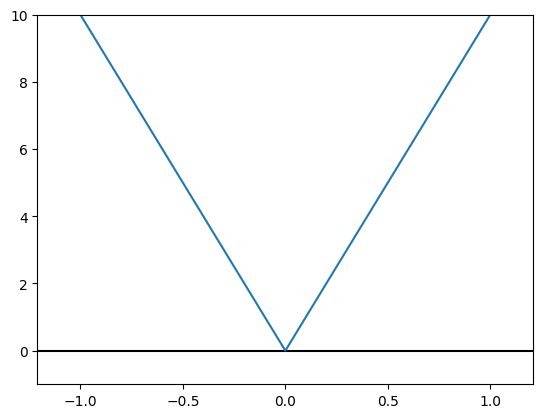

In [76]:
def U(x):
    u0 = 10
    a = 1
    return u0*np.abs(x/a) 
x = np.linspace(-1.1,1.1,1000)
plot_potential(U,x)

c)

In [ ]:
def U(x):
    u0 = 1
    a = 1/4
    return -u0*(np.cosh(x/a))**(-2)

plot_potential(U,x, bounds=(-1.5,0))

2. Transmission coefficients

a)

In [ ]:
def U(x):
    u0, l = 8, 1
    
    u = x*0
    u[x<0] = 0
    u[(x>0)&(x<l)] = u0
    u[x>l] = 0
    return u
x1 = np.linspace(-0.1, 1.1, 1000)

plot_potential(U,x1)


b)

In [ ]:
def U(x):
    u0, a = 8, 1/4
    return u0*np.exp(-np.abs(x/a))

plot_potential(U,x)

c)

In [ ]:
def U(x):
    u0, l = 8, 1
    u = x*0
    u[x<0]=0
    u[(x>0)&(x<l)] = u0*x[(x>0)&(x<l)]/l
    u[x>l]=0
    return u
plot_potential(U,x1)
